In [1]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
from numpy import *
import seaborn as sns

def max2(x):
    if len(x)==1: return x[0]
    x2 = x.copy()#复制一份，不破坏原来的列表
    x2.sort()#从小到大排序
    m1 = x2[-1]#最后一个元素最大
    m2 = x2[-2]#倒数第二个元素第二大
    return (m2+m1)/2  #m1是第二大的值,m2是最大值
def onetwo(l):
    # 找到最小值
    min_value = min(l)
    # 将列表中的最小值替换为1，其余替换为2
    result_list = [1 if x == min_value else 2 for x in l if x is not None]
    return(result_list)

from sklearn import preprocessing

In [2]:
genelist = ['FOS']
distribution={}
for i in genelist:
    distribution[i] = {'on':[],'off':[]}

In [4]:
gene = 'FOS'
for i in glob(r'trace/*_hmm2states.csv'):
    if 2:
        file = i
        trace = pd.read_csv(file)
        hmm_seq = "".join([str(string) for string in list(trace['HMMStates'])])
        sequence = hmm_seq
        #off state
        matches = re.findall(r'1+', sequence)
        lengths = [len(match) for match in matches]
        distribution[gene]['off'] += lengths
        #on state
        matches = re.findall(r'2+', sequence)
        lengths = [len(match) for match in matches]
        distribution[gene]['on'] += lengths

In [10]:
gene_df = pd.DataFrame()
gene_df['gene'] = distribution.keys()
gene_df['off-period'] = [ [item*100/60 for item in  distribution[i]['off']] for i in gene_df['gene']]
gene_df['on-period'] = [ [item*100/60 for item in distribution[i]['on']] for i in gene_df['gene']]
gene_df['off-mean'] = [ mean([item*100/60 for item in  distribution[i]['off']]) for i in gene_df['gene']]
gene_df['on-mean'] = [ mean([item*100/60 for item in distribution[i]['on']]) for i in gene_df['gene']]

gene_df['off-rate'] = [ 1/mean([item*100/60 for item in distribution[i]['on']]) for i in gene_df['gene']]
gene_df['on-rate'] = [ 1/mean([item*100/60 for item in  distribution[i]['off']]) for i in gene_df['gene']]
gene_df['off-median'] = [ median([item*100/60 for item in  distribution[i]['off']]) for i in gene_df['gene']]
gene_df['on-median'] = [ median([item*100/60 for item in distribution[i]['on']]) for i in gene_df['gene']]


gene_df.to_csv('result/gene_onoff.csv',index=None)


ondistribution={}
offdistribution={}

for i in genelist:
    ondistribution[i]=distribution[i]['on']
    offdistribution[i]=distribution[i]['off']

ondf = pd.DataFrame.from_dict(ondistribution, orient='index')
offdf = pd.DataFrame.from_dict(offdistribution, orient='index')

ondf = ondf.T
offdf = offdf.T
ondf.to_csv('result/distribution-onperiod.csv',index=None)
offdf.to_csv('result/distribution-offperiod.csv',index=None)

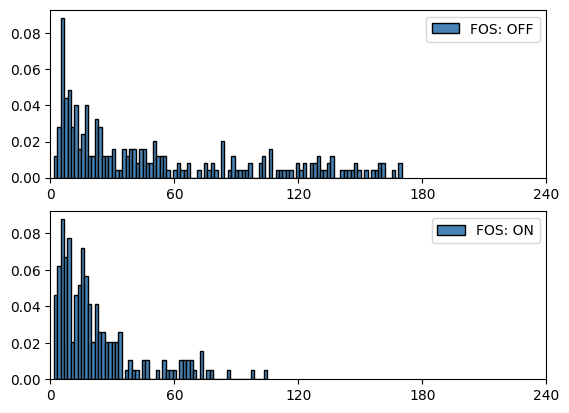

In [12]:
for i in genelist:
    plt.subplot(211)
    plt.hist(distribution[i]['off'], # 绘图数据
        bins = int(max(distribution[i]['off']+[1])), # 指定直方图的条形数
        density = True,
        color = 'steelblue', # 指定填充色
        edgecolor = 'k', # 指定直方图的边界色
        label = i+': OFF' )# 为直方图呈现标签
    plt.legend()
    plt.xlim(0,144) #设置横轴范围为0到4
    plt.xticks(ticks=[0, 36, 72, 108, 144], labels=[0, 60, 120, 180, 240])


    plt.subplot(212)
    plt.hist(distribution[i]['on'], # 绘图数据
        bins = int(max(distribution[i]['on']+[1])), # 指定直方图的条形数
        density = True,
        color = 'steelblue', # 指定填充色
        edgecolor = 'k', # 指定直方图的边界色
        label = i+': ON' )# 为直方图呈现标签
    plt.legend()
    plt.xlim(0,144) #设置横轴范围为0到4
    plt.xticks(ticks=[0, 36, 72, 108, 144], labels=[0, 60, 120, 180, 240])

    plt.savefig('result/plot/onoff-hist-{}.png'.format(i),dpi=300)
    plt.show()

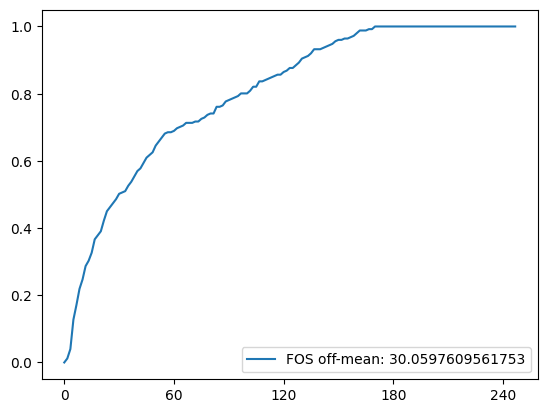

In [14]:
for i in sorted(genelist):
    plt.figure(300)
    if len(distribution[i]['off'])<=0:continue
    hist_data, edges = np.histogram(distribution[i]['off'], bins=np.arange(0, 150 ,1))
    cumulative_data = np.cumsum(hist_data) / len(distribution[i]['off'])
    plt.plot(edges[:-1], cumulative_data,label=i+' off-mean: {}'.format(mean(distribution[i]['off'])))
    plt.legend()
plt.xticks(ticks=[0, 36, 72, 108, 144], labels=[0, 60, 120, 180, 240])

plt.savefig('result/plot/accumulative-off.png'.format(i),dpi=300)
  

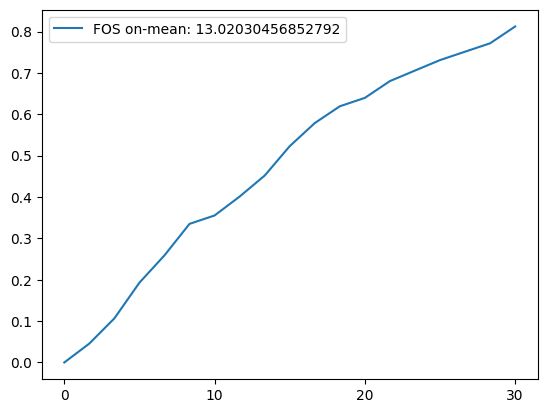

In [16]:
for i in sorted(genelist):    
    plt.figure(300)
    if len(distribution[i]['on'])<=0:continue
    hist_data, edges = np.histogram(distribution[i]['on'], bins=np.arange(0, 20 ,1))
    cumulative_data = np.cumsum(hist_data) / len(distribution[i]['on'])
    plt.plot(edges[:-1], cumulative_data,label=i+' on-mean: {}'.format(mean(distribution[i]['on'])))
    plt.legend()
plt.xticks(ticks=[0, 6, 12, 18], labels=[0, 10, 20, 30])
plt.savefig('result/plot/accumulative-on.png'.format(i),dpi=300)


102
102


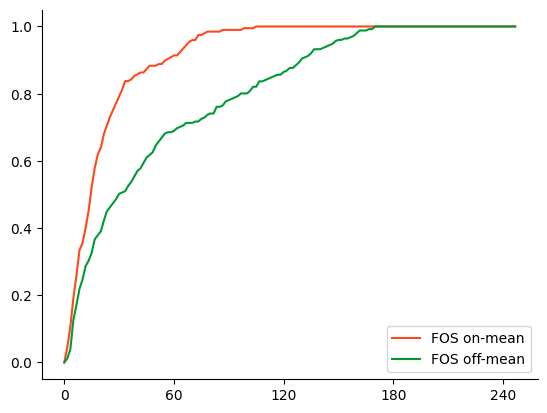

In [23]:
list1 = distribution['FOS']['off']
list2 = distribution['FOS']['off']
print(np.max(list1))
print(np.max(list2))

#------------------------------------------------

i = 'FOS'
plt.figure(300)
hist_data, edges = np.histogram(distribution[i]['on'], bins=np.arange(0, 150 ,1))
cumulative_data = np.cumsum(hist_data) / len(distribution[i]['on'])
plt.plot(edges[:-1], cumulative_data,label=i+' on-mean',color = '#ff481a')

i = 'FOS'
plt.figure(300)
hist_data, edges = np.histogram(distribution[i]['off'], bins=np.arange(0, 150 ,1))
cumulative_data = np.cumsum(hist_data) / len(distribution[i]['off'])
plt.plot(edges[:-1], cumulative_data,label=i+' off-mean',color = '#009933')
plt.legend()

fig = plt.gcf()  # 获取当前图形
for ax in fig.get_axes():  # 遍历图形中的所有坐标轴
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

plt.xticks(ticks=[0, 36, 72, 108, 144], labels=[0, 60, 120, 180, 240])
plt.savefig('result/plot/accumulative-off-green+red.png'.format(i),dpi=300)